# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [1]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [25]:
df = pd.read_csv(r"C:\Users\dell\Downloads\downloaded-file\colorectal_cancer_prediction.csv")
df.head()


,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


In [29]:
#3. Check for Missing Values & Basic Info

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

Patient_ID                 0
Age                        0
Gender                     0
Race                       0
Region                     0
Urban_or_Rural             0
Socioeconomic_Status       0
Family_History             0
Previous_Cancer_History    0
Stage_at_Diagnosis         0
Tumor_Aggressiveness       0
Colonoscopy_Access         0
Screening_Regularity       0
Diet_Type                  0
BMI                        0
Physical_Activity_Level    0
Smoking_Status             0
Alcohol_Consumption        0
Red_Meat_Consumption       0
Fiber_Consumption          0
Insurance_Coverage         0
Time_to_Diagnosis          0
Treatment_Access           0
Chemotherapy_Received      0
Radiotherapy_Received      0
Surgery_Received           0
Follow_Up_Adherence        0
Survival_Status            0
Recurrence                 0
Time_to_Recurrence         0
dtype: int64

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

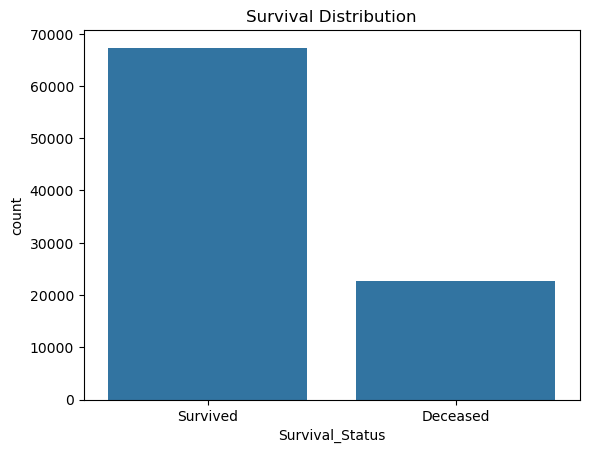

In [37]:
sns.countplot(x='Survival_Status', data=df)
plt.title("Survival Distribution")
plt.show()




In [51]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns
LE = LabelEncoder()

for col in cat_cols:
    df[col] = LE.fit_transform(df[col])
df.head()  # Display the first few rows



,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,Tumor_Aggressiveness,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,71,1,3,2,1,2,1,0,2,0,...,1,0,0,1,0,0,0,1,0,16
1,34,0,1,4,1,2,0,0,0,2,...,0,1,0,0,1,1,1,0,0,28
2,80,0,4,4,1,2,0,0,2,1,...,1,1,1,0,1,1,0,1,0,26
3,40,1,1,4,0,1,0,0,0,2,...,1,0,1,1,0,1,1,0,0,44
4,43,0,4,2,1,0,1,0,2,1,...,0,0,0,1,0,1,1,0,1,20


In [67]:
X = df.drop('Survival_Status', axis=1)
y = df['Survival_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
pd.DataFrame(X_train).head()



,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.084469,0.909441,-0.966668,-1.175645,0.653488,0.892020,1.728272,-0.332906,-1.307002,-0.265430,...,-1.665243,0.496584,0.814951,-0.656630,-1.002365,1.222952,-1.519466,1.224227,-0.65338,0.023160
1,0.629921,0.909441,-0.966668,1.165256,0.653488,-1.670098,-0.578613,3.003851,-0.372637,-1.601137,...,0.899955,0.496584,-1.227067,-0.656630,-1.002365,1.222952,0.658126,1.224227,-0.65338,-0.208322
2,-1.651058,-1.099577,0.911456,-0.395345,0.653488,-0.389039,-0.578613,-0.332906,-1.307002,1.070277,...,-0.382644,0.496584,-1.227067,1.522928,-1.002365,-0.817693,0.658126,1.224227,-0.65338,1.585659
3,-0.014704,0.909441,0.911456,1.165256,0.653488,-0.389039,-0.578613,-0.332906,0.561728,1.070277,...,0.899955,0.496584,0.814951,-0.656630,0.997640,1.222952,0.658126,-0.816842,-0.65338,-0.613414
4,1.324131,-1.099577,-0.340627,1.165256,0.653488,-0.389039,-0.578613,-0.332906,1.496093,1.070277,...,-0.382644,0.496584,0.814951,-0.656630,-1.002365,-0.817693,0.658126,-0.816842,-0.65338,-0.844895


## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [ ]:

# Train a Logistic Regression model


# Predictions

# Model evaluation
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))


In [75]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.7514592250819946
Confusion Matrix:
 [[    0  4471]
 [    0 13518]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      4471
           1       0.75      1.00      0.86     13518

    accuracy                           0.75     17989
   macro avg       0.38      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989

